In [2]:
from mpl_toolkits import mplot3d
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

In [3]:
# NN creation and training will go here
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Define convolutional layers
        # 1 input image channel, 32 output channels, 3x3 square convolution kernel
        # images are 64x64 pixels
        self.main = nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3), padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=(2,2)),
            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=(2,2)),
            torch.nn.Flatten(),
            torch.nn.Linear(64*16*16, 49),
        )
    def forward(self, x):
        out = self.main(x)
        return out


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model=CNN()
model=model.to(device)
summary(model, (1, 1, 64, 64))  # Example input size: batch_size=1, channels=1, height=64, width=64


Using device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 49]                   --
├─Sequential: 1-1                        [1, 49]                   --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           320
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-3                    [1, 32, 32, 32]           --
│    └─Conv2d: 2-4                       [1, 64, 32, 32]           18,496
│    └─ReLU: 2-5                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-6                    [1, 64, 16, 16]           --
│    └─Flatten: 2-7                      [1, 16384]                --
│    └─Linear: 2-8                       [1, 49]                   802,865
Total params: 821,681
Trainable params: 821,681
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 21.05
Input size (MB): 0.02
Forward/backward pass size (MB): 1.57
Params size (MB): 3.29
Estimated Total Siz

In [ ]:
# KMNIST dataset loading
transform = torchvision.transforms.Compose([
        torchvision.transforms.Resize((64, 64)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))])
    

batch_size = 64
trainset = torchvision.datasets.KMNIST(
    root='./archive', train=True, download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)

testset = torchvision.datasets.KMNIST(
    root='./archive', train=False, download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2
)

classes = trainset.classes

In [5]:
# Custom dataset for K49 from .npz files
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class K49Dataset(Dataset):
    def __init__(self, imgs_file, labels_file, transform=None):
        """
        Args:
            imgs_file: Path to the .npz file with images
            labels_file: Path to the .npz file with labels
            transform: Optional transform to be applied on a sample
        """
        imgs_data = np.load(imgs_file)
        labels_data = np.load(labels_file)
        
        self.images = imgs_data['arr_0'] 
        self.labels = labels_data['arr_0']
        self.transform = transform
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])
        
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [7]:
# Create datasets from k-49 files with data augmentation for training
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.RandomRotation(degrees=15), 
    torchvision.transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1), 
        scale=(0.9, 1.1) 
    ),
    torchvision.transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((64, 64)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,))
])

trainset = K49Dataset(
    imgs_file='archive/k49-train-imgs.npz',
    labels_file='archive/k49-train-labels.npz',
    transform=train_transform 
)

testset = K49Dataset(
    imgs_file='archive/k49-test-imgs.npz',
    labels_file='archive/k49-test-labels.npz',
    transform=test_transform
)

batch_size = 64

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2
)

classmap = pd.read_csv('archive/k49_classmap.csv')
print(classmap.head())
classes = classmap.iloc[:, 2].tolist()

   index codepoint char
0      0    U+3042    あ
1      1    U+3044    い
2      2    U+3046    う
3      3    U+3048    え
4      4    U+304A    お


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.28789353..1.9107434].


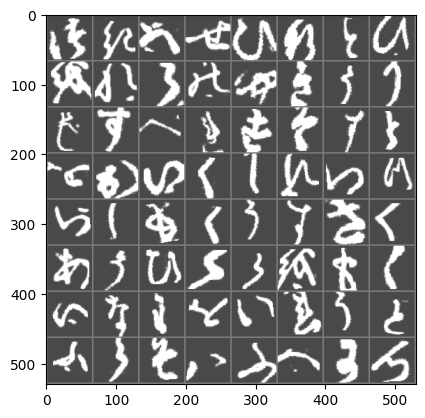

つ     き     は     せ     ひ     な     と     ひ     を     れ     ら     の     や     き     う     り     し     す     へ     れ     す     そ     す     と     を     お     い     く     し     れ     い     つ     い     し     も     く     う     す     さ     く     あ     そ     ひ     ゝ     ら     を     も     ゝ     い     な     わ     を     い     れ     う     と     ふ     ら     そ     は     ふ     へ     に     つ    


In [8]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [10]:
# Define a loss function and optimizer
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [11]:
# Train the network
for epoch in range(50): # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[Epoch {epoch + 1}, Mini-batch {i + 1}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

[Epoch 1, Mini-batch 2000] loss: 1.991
[Epoch 2, Mini-batch 2000] loss: 1.136
[Epoch 3, Mini-batch 2000] loss: 0.965
[Epoch 4, Mini-batch 2000] loss: 0.880
[Epoch 5, Mini-batch 2000] loss: 0.817
[Epoch 6, Mini-batch 2000] loss: 0.772
[Epoch 7, Mini-batch 2000] loss: 0.730
[Epoch 8, Mini-batch 2000] loss: 0.696
[Epoch 9, Mini-batch 2000] loss: 0.674
[Epoch 10, Mini-batch 2000] loss: 0.646
[Epoch 11, Mini-batch 2000] loss: 0.629
[Epoch 12, Mini-batch 2000] loss: 0.607
[Epoch 13, Mini-batch 2000] loss: 0.589
[Epoch 14, Mini-batch 2000] loss: 0.579
[Epoch 15, Mini-batch 2000] loss: 0.565
[Epoch 16, Mini-batch 2000] loss: 0.551
[Epoch 17, Mini-batch 2000] loss: 0.538
[Epoch 18, Mini-batch 2000] loss: 0.525
[Epoch 19, Mini-batch 2000] loss: 0.520
[Epoch 20, Mini-batch 2000] loss: 0.514
[Epoch 21, Mini-batch 2000] loss: 0.502
[Epoch 22, Mini-batch 2000] loss: 0.500
[Epoch 23, Mini-batch 2000] loss: 0.493
[Epoch 24, Mini-batch 2000] loss: 0.485
[Epoch 25, Mini-batch 2000] loss: 0.474
[Epoch 26

In [9]:
# Set path to save and load the model
PATH = './k49_cnn_50_epochs_augmented.pth'

In [13]:
# Save the trained model
torch.save(model.state_dict(), PATH)

In [ ]:
# Load the saved model
model = CNN()
model.load_state_dict(torch.load(PATH))
model.to(device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.28789353..1.9107434].


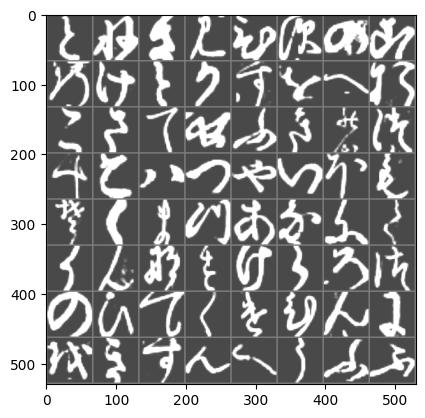

GroundTruth:  と ね さ み ひ す の こ
              の け と か す を へ お
              こ さ て せ ふ き の つ
              へ こ は つ や い ほ も
              そ ゝ ま つ あ な に て
              か ん な す け ら ろ つ
              の ひ て く け ひ ん に
              を き す ん へ う ふ ふ


In [16]:
# Test the network on the test data
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j].item()]}' for j in range(8)))
for j in range(2,9):
    print('             ', ' '.join(f'{classes[labels[j].item()]}' for j in range((j-1)*8, j*8)))


In [17]:
# Test the network on the above data
outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)
print('Predicted:   ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(8)))
for j in range(2,9):
    print('             ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range((j-1)*8, j*8)))

Predicted:    と     ね     さ     み     ひ     つ     の     こ    
              の     け     と     か     す     を     へ     お    
              こ     さ     て     せ     ふ     き     の     つ    
              の     こ     は     つ     や     い     ほ     も    
              き     ゝ     ま     つ     あ     な     ふ     て    
              る     ん     あ     す     け     ら     ろ     つ    
              の     ひ     て     く     を     ひ     ん     に    
              を     き     す     ん     へ     う     ふ     ふ    


In [18]:
# Test the data on the whole test dataset
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        # calculate outputs by running images through the network
        outputs = model(images.to(device))
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the {total} test images: {100 * correct // total} %')

Accuracy of the network on the 38547 test images: 89 %


In [1]:
# Show results per class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images.to(device))
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

NameError: name 'classes' is not defined